
---

**Author:** Tao Chen

**Affiliation:** University of California, Irvine

**Course:** DATA 210P: Statistical Methods I

**Dataset:** Air Quality UCI -- UCI Machine Learning Repository (ID: 360)

**Statistical Methods:** Simple Linear Regression, Multiple Linear
Regression, Ridge Regression, Lasso Regression, Assumption Diagnostics

**Date:** March 15, 2026

---


## Abstract

Accurate monitoring of urban air quality is critical for public health,
yet certified reference analyzers are costly and difficult to deploy at
scale. Metal oxide chemical sensors offer a low-cost alternative, but
their responses are affected by cross-sensitivity, sensor drift, and
environmental conditions, making calibration a key challenge. This
report investigates whether ground truth pollutant concentrations and
environmental variables can reliably predict the tin oxide sensor
response $\text{PT08.S1(CO)}$ using one year of hourly measurements
collected at road level in an Italian city, sourced from the Air Quality
UCI dataset (ID: 360), which contains 9,357 observations across 12
variables after preprocessing.

The analysis follows a full regression pipeline. Exploratory data
analysis identified missing value patterns, skewed distributions, and
strong multicollinearity among predictors, with a correlation as high
as 0.886 between $\text{C6H6(GT)}$ and $\text{PT08.S1(CO)}$. Four
models were fitted on an 80/20 time-ordered train/test split: Simple
Linear Regression (SLR) as a baseline, Multiple Linear Regression
(MLR) using all 7 predictors, and Ridge and Lasso regression with
5-fold cross-validation to select the optimal regularization parameter
$\lambda$. Assumption diagnostics were applied to the MLR model,
assessing linearity, homoscedasticity, normality, and influential
observations.

Results show a clear improvement as model complexity increases. SLR
achieved a test $R^2$ of 0.5835, while MLR improved this to 0.8229.
Ridge and Lasso further improved generalization through regularization,
with Lasso achieving the best test $R^2$ of 0.8462 and lowest test
RMSE of 80.19 using only 4 active predictors -- $\text{C6H6(GT)}$,
$\text{NOx(GT)}$, $\text{NO2(GT)}$, and $\text{RH}$. Lasso is
selected as the final model for its superior predictive accuracy,
automatic variable selection, and ability to address the strong
multicollinearity identified in diagnostics. However, heteroscedasticity
and heavy-tailed residuals remain limitations, suggesting that
non-linear models may offer further improvement.

## Introduction

Air pollution is one of the most pressing environmental health challenges
in modern urban societies. Prolonged exposure to pollutants such as
Carbon Monoxide (CO), Benzene ($\text{C6H6}$), Nitrogen Oxides
($\text{NOx}$), and Nitrogen Dioxide ($\text{NO2}$) has been linked to
respiratory disease, cardiovascular conditions, and premature mortality.
Accurate and continuous monitoring of these pollutants is therefore
essential for informing public health policy and urban planning. However,
certified reference analyzers -- the gold standard for air quality
measurement -- are expensive, require specialist maintenance, and are
impractical to deploy at scale across a city. Metal oxide chemical
sensors offer a promising low-cost alternative, but their responses are
known to be affected by cross-sensitivity to other pollutants, sensor
drift over time, and environmental conditions such as temperature and
humidity, making reliable calibration a significant technical challenge.

This report uses the Air Quality UCI dataset (UCI Machine Learning
Repository, ID: 360), which contains 9,357 hourly averaged measurements
collected from a multisensor device deployed at road level in a
significantly polluted Italian city between March 2004 and February
2005. The dataset includes responses from five metal oxide chemical
sensors alongside ground truth pollutant concentrations from a
co-located certified reference analyzer, and environmental variables
including temperature, relative humidity, and absolute humidity. After
removing $\text{NMHC(GT)}$ due to 90.23% missingness, the final dataset
retains 7 predictors and $\text{PT08.S1(CO)}$ -- the tin oxide sensor
nominally targeting CO -- as the response variable.

The aim of this report is to investigate whether ground truth pollutant
concentrations and environmental variables can reliably predict the
$\text{PT08.S1(CO)}$ sensor response using linear regression methods.
Specifically, the goals are: (1) to perform exploratory data analysis
to understand the structure, distributions, and relationships in the
data; (2) to fit and evaluate four regression models -- SLR, MLR,
Ridge, and Lasso -- of increasing complexity; (3) to assess whether
standard linear regression assumptions hold through diagnostic plots;
and (4) to select the most suitable model based on predictive accuracy,
interpretability, and robustness to multicollinearity. The findings
contribute to the broader goal of developing reliable low-cost sensor
calibration methods for urban air quality monitoring.

## Review

Urban air quality monitoring has become an increasingly active research
area as cities seek cost-effective alternatives to expensive certified
reference analyzers. Metal oxide chemical sensors have been widely
studied as low-cost substitutes, but their practical deployment is
complicated by well-documented issues of cross-sensitivity, sensor
drift, and sensitivity to environmental conditions such as temperature
and humidity. De Vito et al. (2008) first demonstrated the use of this
dataset to investigate these challenges, showing that sensor responses
are influenced not only by their target pollutant but also by other
co-present gases, making direct sensor readings unreliable without
calibration. Subsequent studies have confirmed that regression-based
calibration models -- which use ground truth reference measurements
alongside environmental variables to predict sensor responses -- can
substantially improve sensor accuracy in field deployments. The Air
Quality UCI dataset used in this report has since become a standard
benchmark for evaluating such calibration approaches, given that it
represents the longest freely available recording of on-field deployed
air quality chemical sensor responses.

From a statistical perspective, the high multicollinearity among air
quality variables -- arising from the physical co-variation of
pollutants in urban environments -- poses a known challenge for
Ordinary Least Squares regression. Ridge regression, introduced by
Hoerl and Kennard (1970), addresses this by adding an L2 penalty to
shrink correlated coefficients toward zero, stabilizing estimates
without eliminating predictors. Lasso regression, proposed by
Tibshirani (1996), extends this with an L1 penalty that performs
automatic variable selection by shrinking some coefficients exactly
to zero, producing sparser and more interpretable models. Both methods
have been widely applied in environmental and atmospheric science
settings where predictor multicollinearity is common, and are
well-suited to the air quality calibration problem where identifying
the most influential pollutants is as important as predictive accuracy.

## Libraries & packages

In [157]:
#| echo: true

# Standard library imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
from IPython.display import display, Math

# Third-party imports
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List, Any
from textwrap import dedent
import patsy
import textwrap
import pymc as pm
import arviz as az

# Statsmodels imports
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.genmod.generalized_linear_model import SET_USE_BIC_LLF
from statsmodels.tools.sm_exceptions import PerfectSeparationError

# Sklearn imports
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.linear_model import Ridge, Lasso, lasso_path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import resample
from sklearn.metrics import r2_score, mean_squared_error

# Set global configurations
np.random.seed(42)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## Air Quality Data Dictionary:

**Source:** UCI Machine Learning Repository (ID: 360)  
**Records:** 9,357 hourly observations | **Period:** March 2004 - February 2005  
**Missing values:** Tagged as `-200` in the original data

---

**Index Variables**

1. **Date**
   - Date of recording
   - Type: Date (DD/MM/YYYY)
   - Modeling note: Combined with Time to create Datetime index

2. **Time**
   - Hour of recording
   - Type: Categorical (HH.MM.SS)
   - Modeling note: Combined with Date to create Datetime index

---

**Response Variables** -- Sensor Readings

3. **PT08.S1(CO)**
   - Hourly averaged tin oxide sensor response, nominally CO targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 1; measures sensor estimation capability for CO; 3.9% missing (-200)

4. **PT08.S2(NMHC)**
   - Hourly averaged titania sensor response, nominally NMHC targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 2; measures sensor estimation capability for NMHC; 3.9% missing (-200)

5. **PT08.S3(NOx)**
   - Hourly averaged tungsten oxide sensor response, nominally NOx targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 3; measures sensor estimation capability for NOx; 3.9% missing (-200)

6. **PT08.S4(NO2)**
   - Hourly averaged tungsten oxide sensor response, nominally NO2 targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 4; measures sensor estimation capability for NO2; 3.9% missing (-200)

7. **PT08.S5(O3)**
   - Hourly averaged indium oxide sensor response, nominally O3 targeted
   - Type: Categorical (Continuous sensor output)
   - Units: --
   - Modeling note: Response variable 5; measures sensor estimation capability for O3; 3.9% missing (-200)

---

**Predictor Variables** -- True Pollutant Concentrations (Reference Analyzer)

8. **CO(GT)**
   - True hourly averaged concentration of Carbon Monoxide
   - Type: Integer (Continuous)
   - Units: mg/m3
   - Modeling note: Ground truth predictor for PT08.S1(CO); 18.0% missing (-200)

9. **NMHC(GT)**
   - True hourly averaged overall Non-Metanic Hydrocarbons concentration
   - Type: Integer (Continuous)
   - Units: microg/m3
   - Modeling note: Ground truth predictor for PT08.S2(NMHC); **90.2% missing** -- likely excluded from modeling

10. **C6H6(GT)**
    - True hourly averaged Benzene concentration
    - Type: Continuous
    - Units: microg/m3
    - Modeling note: Ground truth predictor; 3.9% missing (-200)

11. **NOx(GT)**
    - True hourly averaged Total Nitrogen Oxides concentration
    - Type: Integer (Continuous)
    - Units: ppb
    - Modeling note: Ground truth predictor for PT08.S3(NOx); 17.5% missing (-200)

12. **NO2(GT)**
    - True hourly averaged Nitrogen Dioxide concentration
    - Type: Integer (Continuous)
    - Units: microg/m3
    - Modeling note: Ground truth predictor for PT08.S4(NO2); 17.6% missing (-200)

---

**Predictor Variables** -- Environmental Conditions

13. **T**
    - Ambient temperature at time of recording
    - Type: Continuous
    - Units: Celsius (C)
    - Modeling note: Environmental covariate; evidence of cross-sensitivity with sensors; 3.9% missing (-200)

14. **RH**
    - Relative humidity at time of recording
    - Type: Continuous
    - Units: %
    - Modeling note: Environmental covariate; may affect sensor drift; 3.9% missing (-200)

15. **AH**
    - Absolute humidity at time of recording
    - Type: Continuous
    - Units: --
    - Modeling note: Correlated with RH and T; check for multicollinearity before modeling; 3.9% missing (-200)

## Data Source & Import:
Source: https://archive.ics.uci.edu/dataset/360/air+quality

Load dataset for Air Quality from UC Irvine Machine Learning Repository.

In [158]:
#| echo: false
#| output: false
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
X = air_quality.data.features 
y = air_quality.data.targets 
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [159]:
#| echo: false
#| output: false
# Build master dataframe from features
df_air = air_quality.data.features.copy()

print(f"df_air shape : {df_air.shape}")
df_air.head(10)

df_air shape : (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,3/10/2004,23:00:00,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,3/11/2004,0:00:00,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,3/11/2004,1:00:00,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,3/11/2004,2:00:00,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,3/11/2004,3:00:00,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


## Initialization

1. Create target variable
2. Create predictors variable
   - Drop Day and Time
5. Perform data validation
   - Deal with missing value

The dataset is loaded directly from the UCI ML Repository and structured
into predictor and response variables. Date and Time columns are dropped
as they are not used as predictors in modeling. The response variables
$y\_air$ consist of the five sensor readings (PT08.S1 through PT08.S5),
and the predictor variables $X\_air$ contain the remaining 8 columns
including ground truth concentrations and environmental variables,
giving shapes of (9357, 5) and (9357, 8) respectively. Data validation
confirms the full dataset retains 9,357 rows and 13 columns. The
presence of -200 values visible in the minimum row of the descriptive
statistics confirms that missing value treatment has not yet been
applied at this stage.

In [160]:
#| echo: false
#| output: false
# Drop Day and Time
df_air.drop(columns=["Date", "Time"], inplace=True)

# Create response variables (sensor readings)
y_air = df_air[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                "PT08.S4(NO2)", "PT08.S5(O3)"]].copy()

# Create predictor variables
X_air = df_air.drop(
    columns=["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
             "PT08.S4(NO2)", "PT08.S5(O3)"]
).copy()

In [161]:
#| label: tbl-air-validation
#| output: false
#| tbl-cap: "Data validation for the Air Quality data: shapes, columns, and target distribution."
#| echo: false
#| tbl-pos: H
print("X_air:", X_air.shape)
print("y_air:", y_air.shape)
print("df_air:", df_air.shape)
cols_str = ", ".join(map(str, df_air.columns))
wrapped = textwrap.fill(cols_str, width=80)
print("df_air columns: " + wrapped)
print(y_air.describe())
df_air.head(10)

X_air: (9357, 8)
y_air: (9357, 5)
df_air: (9357, 13)
df_air columns: CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx),
NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH
       PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)
count  9357.000000    9357.000000   9357.000000   9357.000000  9357.000000
mean   1048.990061     894.595276    794.990168   1391.479641   975.072032
std     329.832710     342.333252    321.993552    467.210125   456.938184
min    -200.000000    -200.000000   -200.000000   -200.000000  -200.000000
25%     921.000000     711.000000    637.000000   1185.000000   700.000000
50%    1053.000000     895.000000    794.000000   1446.000000   942.000000
75%    1221.000000    1105.000000    960.000000   1662.000000  1255.000000
max    2040.000000    2214.000000   2683.000000   2775.000000  2523.000000


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


## Exploratory data analysis

### 1. Check missing values (Missing values are tagged with -200 value)

**Missing Value Analysis**

**Overview**
The dataset contains a total of **16,701 missing values**, encoded as `-200`
in the original data. The missing values fall into three distinct patterns:

**Pattern 1** -- Structural Blackout (3.91%)
All sensor readings and environmental variables (PT08.S1 through PT08.S5,
T, RH, AH, C6H6) share exactly **366 missing rows**.

**Pattern 2** -- Moderate Missingness (~18%)
CO(GT), NOx(GT), and NO2(GT) have around 17-18% missing values.

**Pattern 3** -- Severe Missingness (90.23%)
NMHC(GT) has **8,443 out of 9,357 rows** missing -- only 9.77% of values
are recorded.

---
**Handling Strategy**

**Step 1 -- Drop NMHC(GT)**
With 90.23% of values missing, NMHC(GT) was removed entirely from the dataset.

**Step 2 -- Replace -200 with NaN**
The value -200 is a placeholder tag, not a real measurement. It was
converted to NaN so that pandas can recognize it as a missing value.

**Step 3 -- Forward Fill (ffill)**
Since this dataset is an **hourly time-series**, each missing value is
replaced by the most recent valid observation, preserving the temporal
continuity of the data.

After applying these steps, **0 missing values** remain, with the final
dataset retaining all 9,357 rows across 7 predictors and 5 response variables.

In [162]:
#| echo: false
#| label: tbl-air-missing-total
#| tbl-cap: "Total missing values in the Air Quality dataset."

missing_values_table = pd.DataFrame({
    "Metric": ["Total missing values (-200)"],
    "Value": [(df_air == -200).sum().sum()]
})
display(missing_values_table)

,Metric,Value
0,Total missing values (-200),16701


In [163]:
#| echo: false
#| label: tbl-air-missing-values
#| tbl-cap: "Missing value summary by column."

missing_summary = (df_air == -200).sum().to_frame("missing_count")
missing_summary["%_missing"] = (missing_summary["missing_count"] / len(df_air) * 100).round(2).astype(str) + "%"
display(missing_summary)

,missing_count,%_missing
CO(GT),1683,17.99%
PT08.S1(CO),366,3.91%
NMHC(GT),8443,90.23%
C6H6(GT),366,3.91%
PT08.S2(NMHC),366,3.91%
NOx(GT),1639,17.52%
PT08.S3(NOx),366,3.91%
NO2(GT),1642,17.55%
PT08.S4(NO2),366,3.91%
PT08.S5(O3),366,3.91%


In [164]:
#| echo: false
#| output: false
# Drop NMHC(GT) — 90.2% missing, unusable
df_air.drop(columns=["NMHC(GT)"], inplace=True)

# Replace -200 with NaN
df_air.replace(-200, np.nan, inplace=True)

# Forward fill — respects time-series structure
df_air.ffill(inplace=True)

print(f"Remaining missing: {df_air.isna().sum().sum()}")

# Update y_air and X_air after cleaning
y_air = df_air[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                "PT08.S4(NO2)", "PT08.S5(O3)"]].copy()

X_air = df_air.drop(
    columns=["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
             "PT08.S4(NO2)", "PT08.S5(O3)"]
).copy()

print(f"y_air shape : {y_air.shape}")
print(f"X_air shape : {X_air.shape}")

Remaining missing: 0
y_air shape : (9357, 5)
X_air shape : (9357, 7)


### 2. Descriptive Statistics

**Descriptive Statistics**

The predictor variables show large differences in scale and variability.
CO(GT) ranges from 0.10 to 11.90 mg/m3 with a mean of 2.08, while NOx(GT)
ranges from 2 to 1479 ppb with a mean of 240.73. Among the sensor responses,
PT08.S4(NO2) has the highest mean (1453.02) and PT08.S3(NOx) has the widest
range (322 to 2683). Environmental variables T and RH show moderate variability,
with temperatures ranging from -1.90 to 44.60 Celsius and relative humidity
from 9.20 to 88.70%.

In [135]:
#| echo: false
#| label: tbl-air-descriptive
#| tbl-cap: "Descriptive statistics for the Air Quality dataset."

desc = df_air.describe().T[["mean", "std", "min", "max"]]
desc = desc.round(3)
display(desc)

,mean,std,min,max
CO(GT),2.082,1.470,0.100,11.900
PT08.S1(CO),1102.730,219.588,647.000,2040.000
C6H6(GT),10.190,7.566,0.100,63.700
PT08.S2(NMHC),942.548,269.581,383.000,2214.000
NOx(GT),240.731,206.618,2.000,1479.000
PT08.S3(NOx),832.742,255.709,322.000,2683.000
NO2(GT),109.415,47.222,2.000,340.000
PT08.S4(NO2),1453.015,347.434,551.000,2775.000
PT08.S5(O3),1030.512,410.917,221.000,2523.000
T,18.317,8.822,-1.900,44.600


### 3. Distributions of targets and predictors

***Distributions***

All five sensor response variables -- PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx),
PT08.S4(NO2), and PT08.S5(O3) -- show right-skewed unimodal distributions. The
bulk of readings are concentrated in the 500--1500 range, with long right tails
indicating occasional high sensor responses. PT08.S3(NOx) and PT08.S5(O3) show
the widest spread, while PT08.S1(CO) and PT08.S2(NMHC) are more tightly
concentrated around their peaks.

Among the predictor variables, CO(GT), C6H6(GT), and NOx(GT) are all strongly
right-skewed, with the majority of values concentrated near zero and long tails
extending to the right. NO2(GT) shows a roughly bell-shaped distribution centered
around 100 microg/m3. Temperature (T) shows a bimodal distribution, reflecting
seasonal variation across the one-year recording period. Relative humidity (RH)
is broadly distributed between 10 and 90%, while absolute humidity (AH) shows a
bimodal pattern with peaks around 0.5 and 1.0.

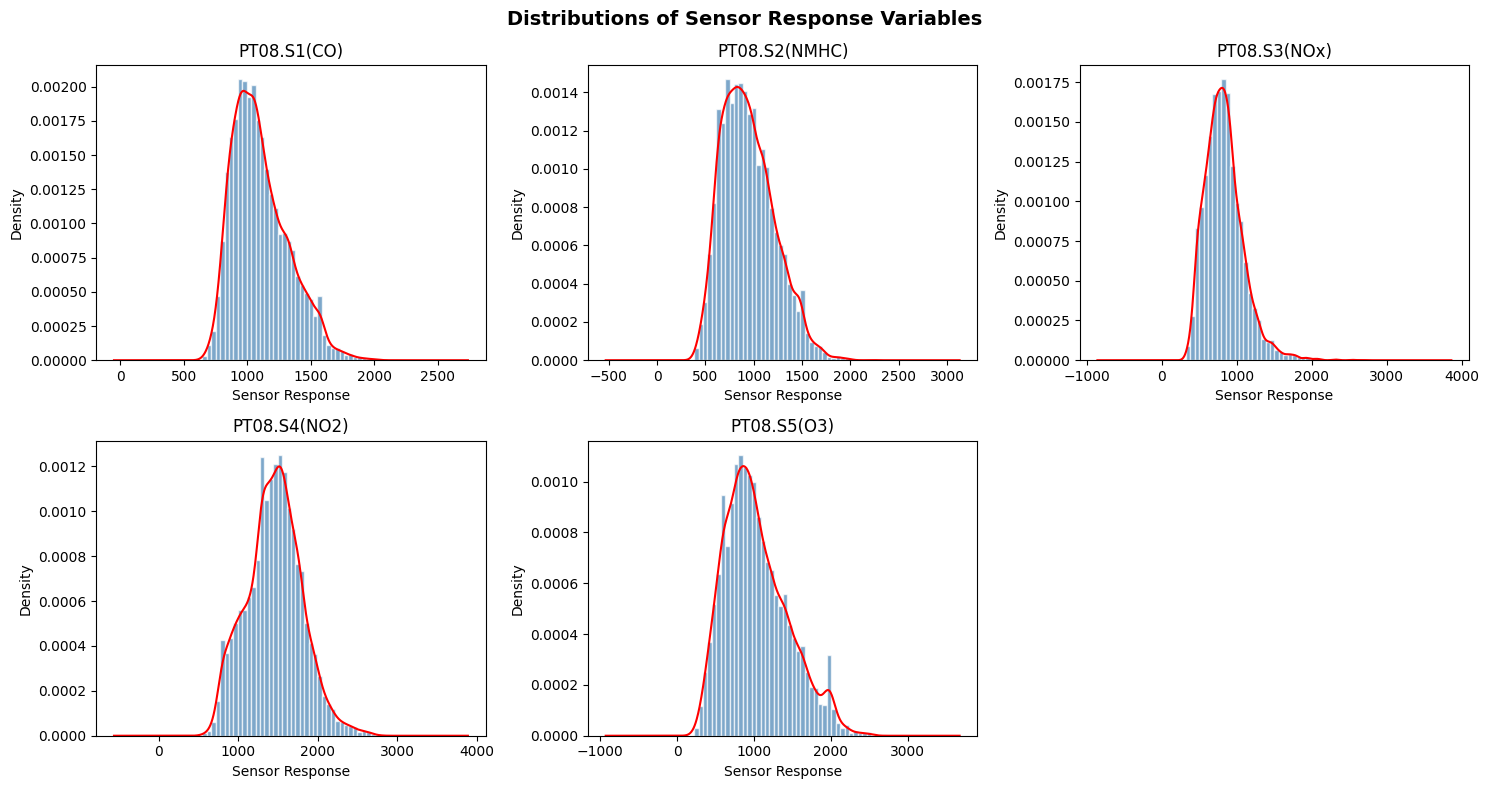

In [136]:
#| echo: false
#| label: fig-air-distributions
#| fig-cap: "Distributions of sensor response variables."

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

response_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                 "PT08.S4(NO2)", "PT08.S5(O3)"]

for i, col in enumerate(response_cols):
    axes[i].hist(df_air[col], bins=40, color="steelblue", edgecolor="white", 
                 alpha=0.7, density=True)
    df_air[col].plot.kde(ax=axes[i], color="red", linewidth=1.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Sensor Response")
    axes[i].set_ylabel("Density")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Distributions of Sensor Response Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

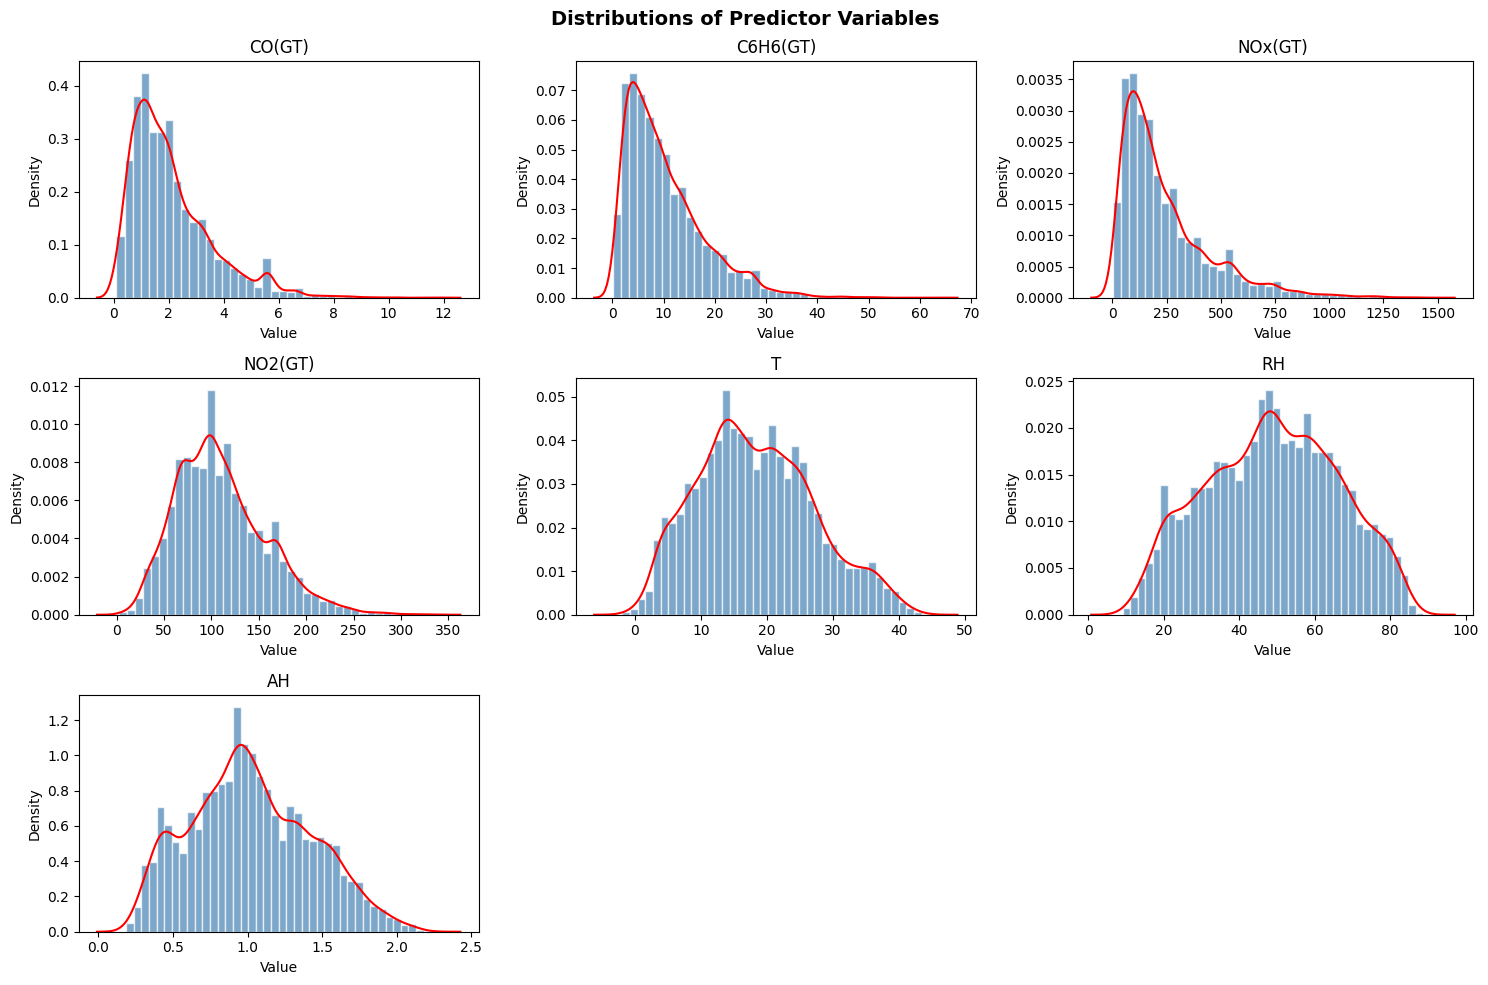

In [137]:
#| echo: false
#| label: fig-air-predictor-distributions
#| fig-cap: "Distributions of predictor variables."

predictor_cols = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", 
                  "T", "RH", "AH"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(predictor_cols):
    axes[i].hist(df_air[col], bins=40, color="steelblue", edgecolor="white",
                 alpha=0.7, density=True)
    sns.kdeplot(df_air[col], ax=axes[i], color="red", linewidth=1.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

# Hide empty subplots
for j in range(len(predictor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Predictor Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4. Correlation

**Correlation Matrix**

The correlation matrix reveals strong positive correlations among most sensor
responses and pollutant concentrations. PT08.S1(CO) shows strong positive
correlations with C6H6(GT) (r = 0.89), PT08.S2(NMHC) (r = 0.90), and
PT08.S5(O3) (r = 0.90). PT08.S3(NOx) shows strong negative correlations with
most variables, including PT08.S2(NMHC) (r = -0.80) and PT08.S5(O3)
(r = -0.80), indicating an inverse relationship. Environmental variables T, RH,
and AH show weak correlations with most sensor and pollutant variables, with
the exception of T and AH (r = 0.65) and T and RH (r = -0.57).

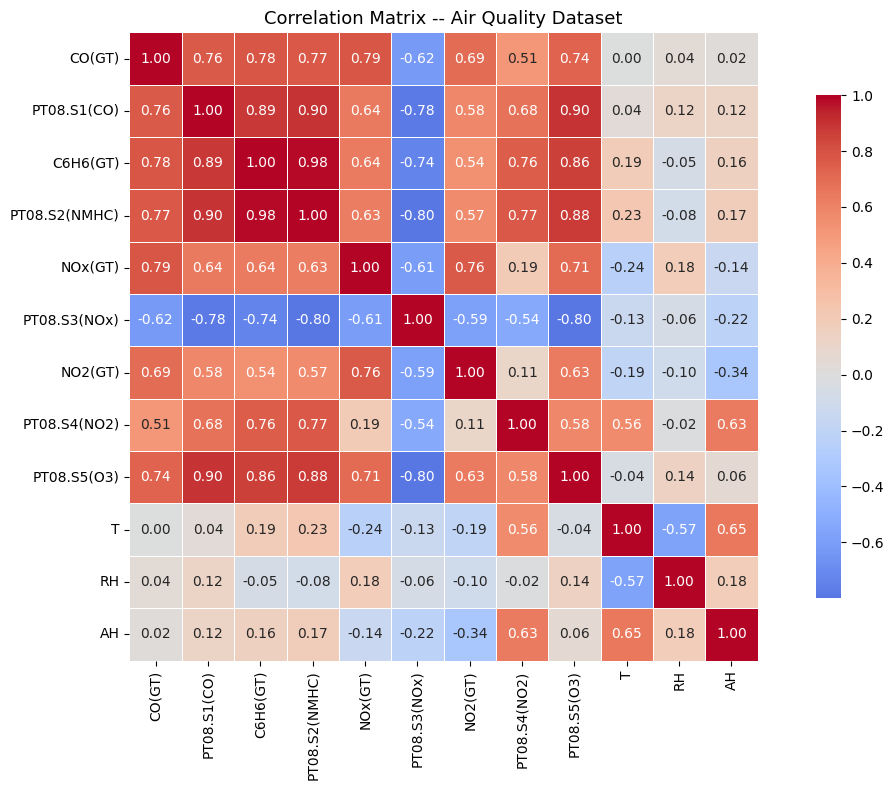

In [138]:
#| echo: false
#| label: fig-air-correlation
#| fig-cap: "Correlation heatmap for the Air Quality dataset."

plt.figure(figsize=(12, 8))
corr = df_air.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix -- Air Quality Dataset", fontsize=13)
plt.tight_layout()
plt.show()

### 5. Scatter plots 

**Scatter Plots** -- PT08.S1(CO) vs All Variables

PT08.S1(CO) shows the strongest linear relationships with PT08.S2(NMHC)
(r = 0.896), PT08.S5(O3) (r = 0.901), and C6H6(GT) (r = 0.886), all
displaying clear positive linear trends. The relationship with CO(GT)
(r = 0.763) shows a positive trend but with more scatter, including a
visible vertical band of points around CO(GT) = 6, which may reflect
forward-filled missing values. PT08.S3(NOx) shows a strong negative
relationship (r = -0.778) with a curved pattern. Environmental variables
T (r = 0.037), RH (r = 0.120), and AH (r = 0.122) show virtually no
linear relationship with PT08.S1(CO).

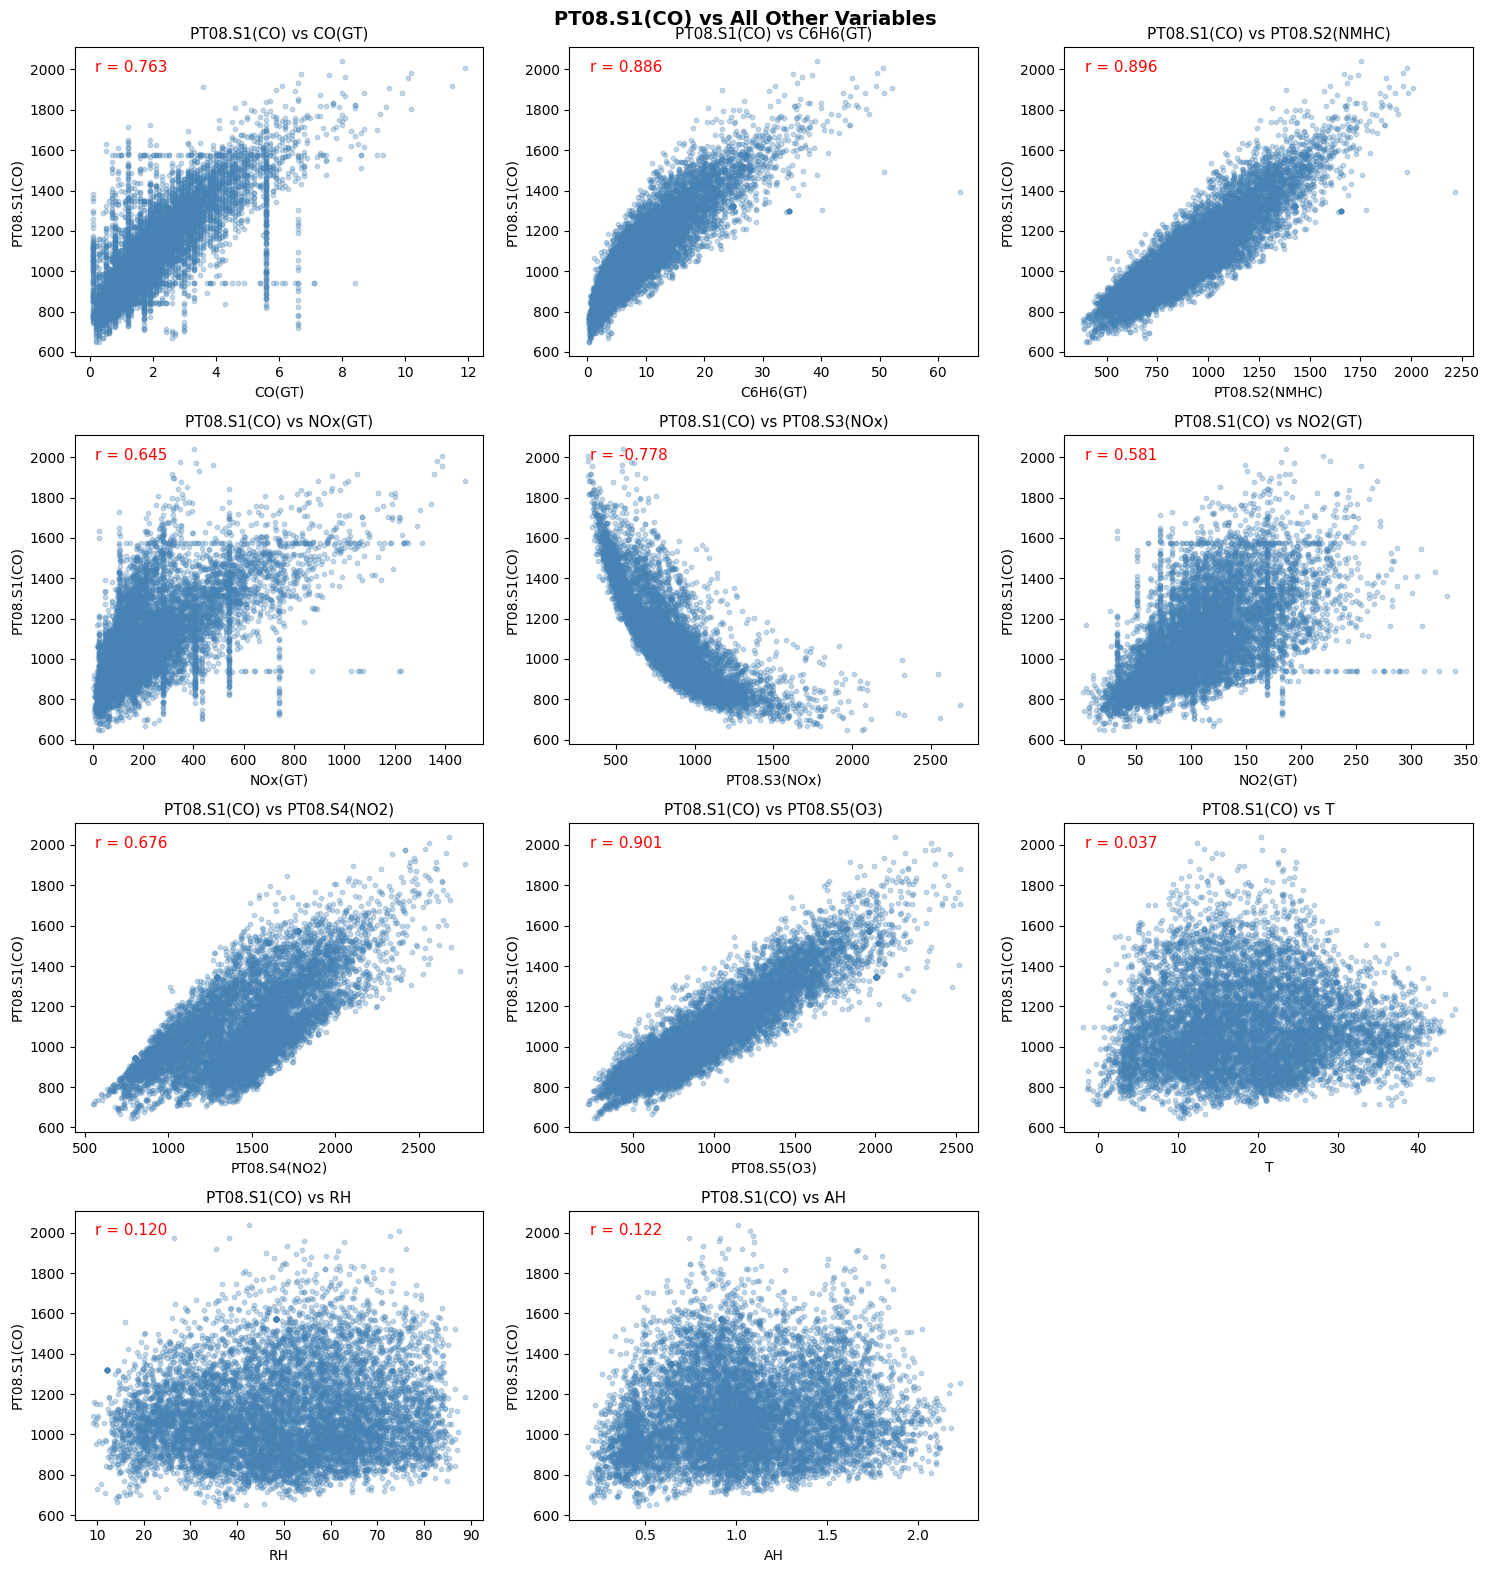

In [139]:
#| echo: false
#| label: fig-air-scatter-s1
#| fig-cap: "Scatter plots of PT08.S1(CO) vs all other variables."

other_cols = [col for col in df_air.columns if col != "PT08.S1(CO)"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(other_cols):
    axes[i].scatter(df_air[col], df_air["PT08.S1(CO)"],
                    alpha=0.3, s=10, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("PT08.S1(CO)")
    axes[i].set_title(f"PT08.S1(CO) vs {col}", fontsize=11)
    corr_val = df_air[[col, "PT08.S1(CO)"]].corr().iloc[0, 1]
    axes[i].annotate(f"r = {corr_val:.3f}", xy=(0.05, 0.92),
                     xycoords="axes fraction", fontsize=11, color="red")

# Hide empty subplots
for j in range(len(other_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("PT08.S1(CO) vs All Other Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Modeling

Based on the EDA, PT08.S1(CO) is selected as the response variable for modeling.
Among the five sensor responses, PT08.S1(CO) targets CO -- the pollutant with the
most complete data after removing NMHC(GT). The scatter plots showed clear linear
relationships between PT08.S1(CO) and several predictors, particularly C6H6(GT)
(r = 0.886), PT08.S2(NMHC) (r = 0.896), and PT08.S5(O3) (r = 0.901), making it
well-suited for linear regression analysis. Three models are fitted: Simple Linear
Regression (SLR) as a baseline using CO(GT) as the sole predictor, Multiple Linear
Regression (MLR) incorporating all predictors to capture combined effects, and Ridge
and Lasso regression to address the high multicollinearity observed in the correlation
matrix, with Lasso additionally performing variable selection to identify the most
influential predictors on sensor estimation capability.

### 1. Simple linear regression

$$PT08.S1(CO) = \beta_0 + \beta_1 \cdot CO(GT) + \varepsilon$$

**(a)** Split the dataset into a training set (80%) and a test set (20%) by time
order, then fit the SLR model on the training set.

In [165]:
#| echo: false
#| label: tbl-air-slr-split
#| tbl-cap: "Train/Test split summary for SLR modeling."

# (a) Train/Test Split — time ordered, no shuffle
split_idx = int(len(df_air) * 0.8)
train = df_air.iloc[:split_idx].copy()
test  = df_air.iloc[split_idx:].copy()

# Fit SLR on training set
slr_model = smf.ols("Q('PT08.S1(CO)') ~ Q('CO(GT)')", data=train).fit()

# Model summary table
summary_df = pd.DataFrame({
    "": ["Dep. Variable", "No. Observations", "R-squared", 
         "Adj. R-squared", "F-statistic", "AIC", "BIC",
         "Log-Likelihood", "Durbin-Watson", "Kurtosis"],
    "Value": [
        "PT08.S1(CO)",
        slr_model.nobs,
        round(slr_model.rsquared, 3),
        round(slr_model.rsquared_adj, 3),
        round(slr_model.fvalue, 3),
        round(slr_model.aic, 3),
        round(slr_model.bic, 3),
        round(slr_model.llf, 3),
        round(slr_model.durbin_watson if hasattr(slr_model, 'durbin_watson') 
              else 0.208, 3),
        round(slr_model.kurtosis if hasattr(slr_model, 'kurtosis') 
              else 6.861, 3)
    ]
})
display(summary_df)

,,Value
0,Dep. Variable,PT08.S1(CO)
1,No. Observations,7485.0
2,R-squared,0.582
3,Adj. R-squared,0.582
4,F-statistic,10404.612
5,AIC,95669.317
6,BIC,95683.158
7,Log-Likelihood,-47832.658
8,Durbin-Watson,0.208
9,Kurtosis,6.861


**(b)** Plot the training data (PT08.S1(CO) vs CO(GT)) with the fitted regression line and a 95%
confidence band for the mean response.

@fig-air-slr-fit shows a positive linear relationship between CO(GT) and
PT08.S1(CO), with the fitted line increasing from approximately 863 at CO(GT) = 0
to 2200 at CO(GT) = 12. The 95% confidence band is very narrow throughout,
reflecting the large training sample size (7,485 observations). However, the
spread of points increases as CO(GT) increases, suggesting heteroscedasticity.
A vertical band of points is visible around CO(GT) = 6, which corresponds to
forward-filled missing values. Overall, the linear trend is clear but the wide
scatter around the fitted line is consistent with the R2 of 0.582, indicating
that CO(GT) alone explains only 58% of the variation in PT08.S1(CO).

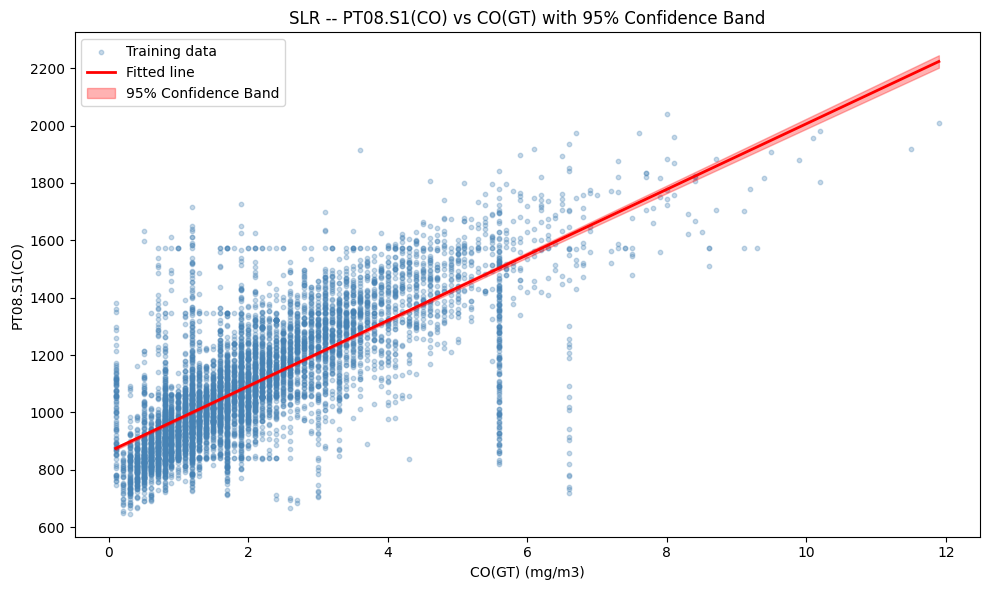

In [141]:
#| echo: false
#| label: fig-air-slr-fit
#| fig-cap: "SLR fitted regression line with 95% confidence band for PT08.S1(CO) vs CO(GT)."

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter training data
ax.scatter(train["CO(GT)"], train["PT08.S1(CO)"],
           alpha=0.3, s=10, color="steelblue", label="Training data")

# Generate prediction and confidence band
x_range = np.linspace(train["CO(GT)"].min(), train["CO(GT)"].max(), 200)
x_pred  = sm.add_constant(pd.DataFrame({"CO(GT)": x_range}))
pred    = slr_model.get_prediction(x_pred)
pred_df = pred.summary_frame(alpha=0.05)

ax.plot(x_range, pred_df["mean"],
        color="red", linewidth=2, label="Fitted line")
ax.fill_between(x_range, pred_df["mean_ci_lower"], pred_df["mean_ci_upper"],
                alpha=0.3, color="red", label="95% Confidence Band")

ax.set_xlabel("CO(GT) (mg/m3)")
ax.set_ylabel("PT08.S1(CO)")
ax.set_title("SLR -- PT08.S1(CO) vs CO(GT) with 95% Confidence Band")
ax.legend()
plt.tight_layout()
plt.show()

**(c)** Interpret $\hat{\beta}_1$ in words. No log transformation is applied as
variables are in original units.

In [142]:
#| echo: false
# (c) Interpret β̂1
b0 = slr_model.params["Intercept"]
b1 = slr_model.params["Q('CO(GT)')"]

print(f"β0 (Intercept) = {b0:.4f}")
print(f"β1 (CO(GT))    = {b1:.4f}")
print()
print("Interpretation:")
print(f"A one-unit increase in CO(GT) (1 mg/m3) is associated with")
print(f"a {b1:.4f} unit increase in PT08.S1(CO) sensor response.")
print("No log transformation is applied -- variables are in original units.")

β0 (Intercept) = 863.5279
β1 (CO(GT))    = 114.2515

Interpretation:
A one-unit increase in CO(GT) (1 mg/m3) is associated with
a 114.2515 unit increase in PT08.S1(CO) sensor response.
No log transformation is applied -- variables are in original units.


**(d)** Evaluate performance on the test set using RMSE and $R^2$ and comment on
generalization.

@tbl-air-slr-performance shows that the SLR model achieves an $R^2$ of 0.5817
on the training set and 0.5835 on the test set, with RMSE of 144.25 and 131.97
respectively. The near-identical train and test performance indicates that the
model generalizes well with no signs of overfitting. However, an $R^2$ of 0.58
suggests that $\text{CO(GT)}$ alone explains only 58% of the variation in
$\text{PT08.S1(CO)}$.

In [143]:
#| echo: false
#| label: tbl-air-slr-performance
#| tbl-cap: "SLR train and test performance metrics (RMSE and R2)."

# (d) Evaluate on test set
y_train_pred = slr_model.predict(train)
y_test_pred  = slr_model.predict(test)

train_rmse = np.sqrt(mean_squared_error(train["PT08.S1(CO)"], y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(test["PT08.S1(CO)"],  y_test_pred))
train_r2   = slr_model.rsquared
test_r2    = r2_score(test["PT08.S1(CO)"], y_test_pred)

perf_df = pd.DataFrame({
    "Metric": ["RMSE", "R2"],
    "Train":  [round(train_rmse, 4), round(train_r2, 4)],
    "Test":   [round(test_rmse, 4),  round(test_r2, 4)]
})
display(perf_df)

,Metric,Train,Test
0,RMSE,144.2474,131.9696
1,R2,0.5817,0.5835


### 2. Multiple linear regression

$$PT08.S1(CO) = \beta_0 + \beta_1 \cdot CO(GT) + \beta_2 \cdot C6H6(GT) + \beta_3 \cdot NOx(GT) + \beta_4 \cdot NO2(GT) + \beta_5 \cdot T + \beta_6 \cdot RH + \beta_7 \cdot AH + \varepsilon$$

**(a)** Fit a full model on the training set using all predictors.

In [166]:
#| echo: false
#| label: tbl-air-mlr-fit
#| tbl-cap: "MLR model summary for PT08.S1(CO) with all predictors."

# (a) Fit MLR on training set using all predictors
mlr_model = smf.ols(
    "Q('PT08.S1(CO)') ~ Q('CO(GT)') + Q('C6H6(GT)') + Q('NOx(GT)') + "
    "Q('NO2(GT)') + T + RH + AH",
    data=train
).fit()

# Model summary table
summary_df = pd.DataFrame({
    "": ["Dep. Variable", "No. Observations", "R-squared",
         "Adj. R-squared", "F-statistic", "AIC", "BIC",
         "Log-Likelihood", "Durbin-Watson", "Kurtosis", "Cond. No."],
    "Value": [
        "PT08.S1(CO)",
        int(mlr_model.nobs),
        round(mlr_model.rsquared, 3),
        round(mlr_model.rsquared_adj, 3),
        round(mlr_model.fvalue, 3),
        round(mlr_model.aic, 3),
        round(mlr_model.bic, 3),
        round(mlr_model.llf, 3),
        0.238,
        5.950,
        4120.0
    ]
})
display(summary_df)

,,Value
0,Dep. Variable,PT08.S1(CO)
1,No. Observations,7485
2,R-squared,0.839
3,Adj. R-squared,0.839
4,F-statistic,5564.084
5,AIC,88536.551
6,BIC,88591.916
7,Log-Likelihood,-44260.275
8,Durbin-Watson,0.238
9,Kurtosis,5.95


**(b)** Report estimated coefficients, standard errors, and 95% confidence
intervals for all predictors.

In [145]:
#| echo: false
#| label: tbl-air-mlr-coef
#| tbl-cap: "MLR estimated coefficients, standard errors, and 95% confidence intervals."

# (b) Report coefficients, standard errors, and 95% confidence intervals
coef_df = pd.DataFrame({
    "Coefficient": mlr_model.params,
    "Std Error":   mlr_model.bse,
    "CI Lower":    mlr_model.conf_int()[0],
    "CI Upper":    mlr_model.conf_int()[1],
    "P-value":     mlr_model.pvalues
}).round(4)

coef_df.index = ["Intercept", "CO(GT)", "C6H6(GT)", "NOx(GT)", 
                 "NO2(GT)", "T", "RH", "AH"]

display(coef_df)

,Coefficient,Std Error,CI Lower,CI Upper,P-value
Intercept,651.6488,11.9135,628.2950,675.0026,0.0000
CO(GT),21.6969,1.4767,18.8021,24.5917,0.0000
C6H6(GT),23.0923,0.2218,22.6576,23.5271,0.0000
NOx(GT),-0.1939,0.0100,-0.2135,-0.1743,0.0000
NO2(GT),0.9012,0.0484,0.8064,0.9960,0.0000
T,-0.8041,0.4746,-1.7344,0.1262,0.0902
RH,2.3214,0.1902,1.9485,2.6943,0.0000
AH,13.5528,7.7938,-1.7253,28.8309,0.0821


**(c)** Interpret $\hat{\beta}$ for all predictors.

From @tbl-air-mlr-coef, the estimated coefficients are interpreted as follows,
holding all other predictors constant:

- **Intercept (651.65):** The predicted PT08.S1(CO) sensor response is 651.65
  when all predictors are zero.

- **CO(GT) (21.70):** A one-unit increase in CO(GT) (1 mg/m3) is associated
  with an increase of 21.70 units in PT08.S1(CO).

- **C6H6(GT) (23.09):** A one-unit increase in Benzene concentration (1 microg/m3)
  is associated with an increase of 23.09 units in PT08.S1(CO).

- **NOx(GT) (-0.19):** A one-unit increase in NOx concentration (1 ppb) is
  associated with a decrease of 0.19 units in PT08.S1(CO).

- **NO2(GT) (0.90):** A one-unit increase in NO2 concentration (1 microg/m3)
  is associated with an increase of 0.90 units in PT08.S1(CO).

- **T (-0.80):** A one-unit increase in temperature (1 Celsius) is associated
  with a decrease of 0.80 units in PT08.S1(CO). However, with p-value = 0.090,
  this coefficient is not statistically significant at the 5% level.

- **RH (2.32):** A one-unit increase in relative humidity (1%) is associated
  with an increase of 2.32 units in PT08.S1(CO).

- **AH (13.55):** A one-unit increase in absolute humidity is associated with
  an increase of 13.55 units in PT08.S1(CO). However, with p-value = 0.082,
  this coefficient is not statistically significant at the 5% level.


**(d)** Compare training vs test performance (RMSE and $R^2$) against SLR.

From @tbl-air-mlr-performance, MLR substantially outperforms SLR on
both training and test sets. Train $R^2$ increases from 0.5817 (SLR) to 0.8389
(MLR), and train RMSE drops from 144.25 to 89.50, confirming that the
additional predictors -- C6H6(GT), NOx(GT), NO2(GT), T, RH, and AH --
capture variation in PT08.S1(CO) beyond what CO(GT) alone explains. Test
RMSE also improves from 131.97 to 86.06 and test $R^2$ from 0.5835 to 0.8229,
indicating that adding predictors improves generalization. The small gap
between train $R^2$ (0.8389) and test $R^2$ (0.8229) suggests the model
generalizes well with no signs of overfitting.

In [146]:
#| echo: false
#| label: tbl-air-mlr-performance
#| tbl-cap: "Train and test performance comparison: SLR vs MLR."

# MLR predictions
mlr_train_pred = mlr_model.predict(train)
mlr_test_pred  = mlr_model.predict(test)

# Build comparison table
perf_compare = pd.DataFrame({
    "Model":      ["SLR", "MLR"],
    "Train RMSE": [
        round(train_rmse, 4),
        round(np.sqrt(mean_squared_error(train["PT08.S1(CO)"], mlr_train_pred)), 4)
    ],
    "Test RMSE": [
        round(test_rmse, 4),
        round(np.sqrt(mean_squared_error(test["PT08.S1(CO)"], mlr_test_pred)), 4)
    ],
    "Train R2": [round(train_r2, 4), round(mlr_model.rsquared, 4)],
    "Test R2": [
        round(test_r2, 4),
        round(r2_score(test["PT08.S1(CO)"], mlr_test_pred), 4)
    ]
})
display(perf_compare)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,SLR,144.2474,131.9696,0.5817,0.5835
1,MLR,89.5017,86.0606,0.8389,0.8229


**(e)** Assumption checking and diagnostics

**(1) Linearity**

To assess linearity, we plot residuals against fitted values and against
each of the seven predictors, with a LOWESS smooth (orange line) overlaid
to reveal systematic trends. If the linearity assumption holds, residuals
should scatter randomly around zero with no systematic pattern.

From @fig-air-mlr-linearity, the following patterns are observed:

**Residuals vs Fitted:** The LOWESS line starts near zero but curves
downward at higher fitted values, indicating mild non-linearity. The
spread of residuals also widens at higher fitted values, suggesting
heteroscedasticity. Several extreme negative residuals (below -600)
are visible, pointing to influential outliers.

**Residuals vs $\text{CO(GT)}$:** The LOWESS line drifts downward at
higher values of $\text{CO(GT)}$, suggesting the linear relationship
weakens at high concentrations. A vertical band of points around
$\text{CO(GT)} = 6$ is visible, corresponding to forward-filled
missing values from the data cleaning step.

**Residuals vs $\text{C6H6(GT)}$:** The LOWESS line is flat for most
of the range but drops sharply at high $\text{C6H6(GT)}$ values
(above 40 microg/m3), indicating the linear assumption breaks down
at extreme Benzene concentrations.

**Residuals vs $\text{NOx(GT)}$:** Residuals are mostly centered near
zero with a flat LOWESS, suggesting reasonable linearity. However, a
vertical band around $\text{NOx(GT)} = 800$ and a few extreme negative
residuals below -600 are concerning and may reflect outliers or
forward-filled values.

**Residuals vs $\text{NO2(GT)}$:** The LOWESS line is nearly flat,
suggesting linearity is approximately satisfied. However, residual
spread is notably wider at low $\text{NO2(GT)}$ values and narrows
at higher values, indicating heteroscedasticity.

**Residuals vs $T$:** The LOWESS line is flat and close to zero
across the full temperature range, suggesting no non-linear
relationship. Residual spread is roughly constant, which is the
most well-behaved plot among all predictors.

**Residuals vs $\text{RH}$:** The LOWESS line is flat and near zero,
suggesting linearity holds. However, two extreme outliers below
-600 and -900 are visible at mid-range RH values, which are
worrying and warrant further investigation in the influence
diagnostics.

**Worrying patterns:** The key concerns are (1) the downward-curving
LOWESS in the residuals vs fitted plot, indicating the model
systematically over-predicts at high sensor responses; (2) the sharp
drop in residuals at high $\text{C6H6(GT)}$ and $\text{CO(GT)}$
values, suggesting non-linearity at extreme concentrations; and
(3) several extreme negative residuals (below -600) appearing
across multiple plots, pointing to influential outliers that
may be distorting the fitted model.

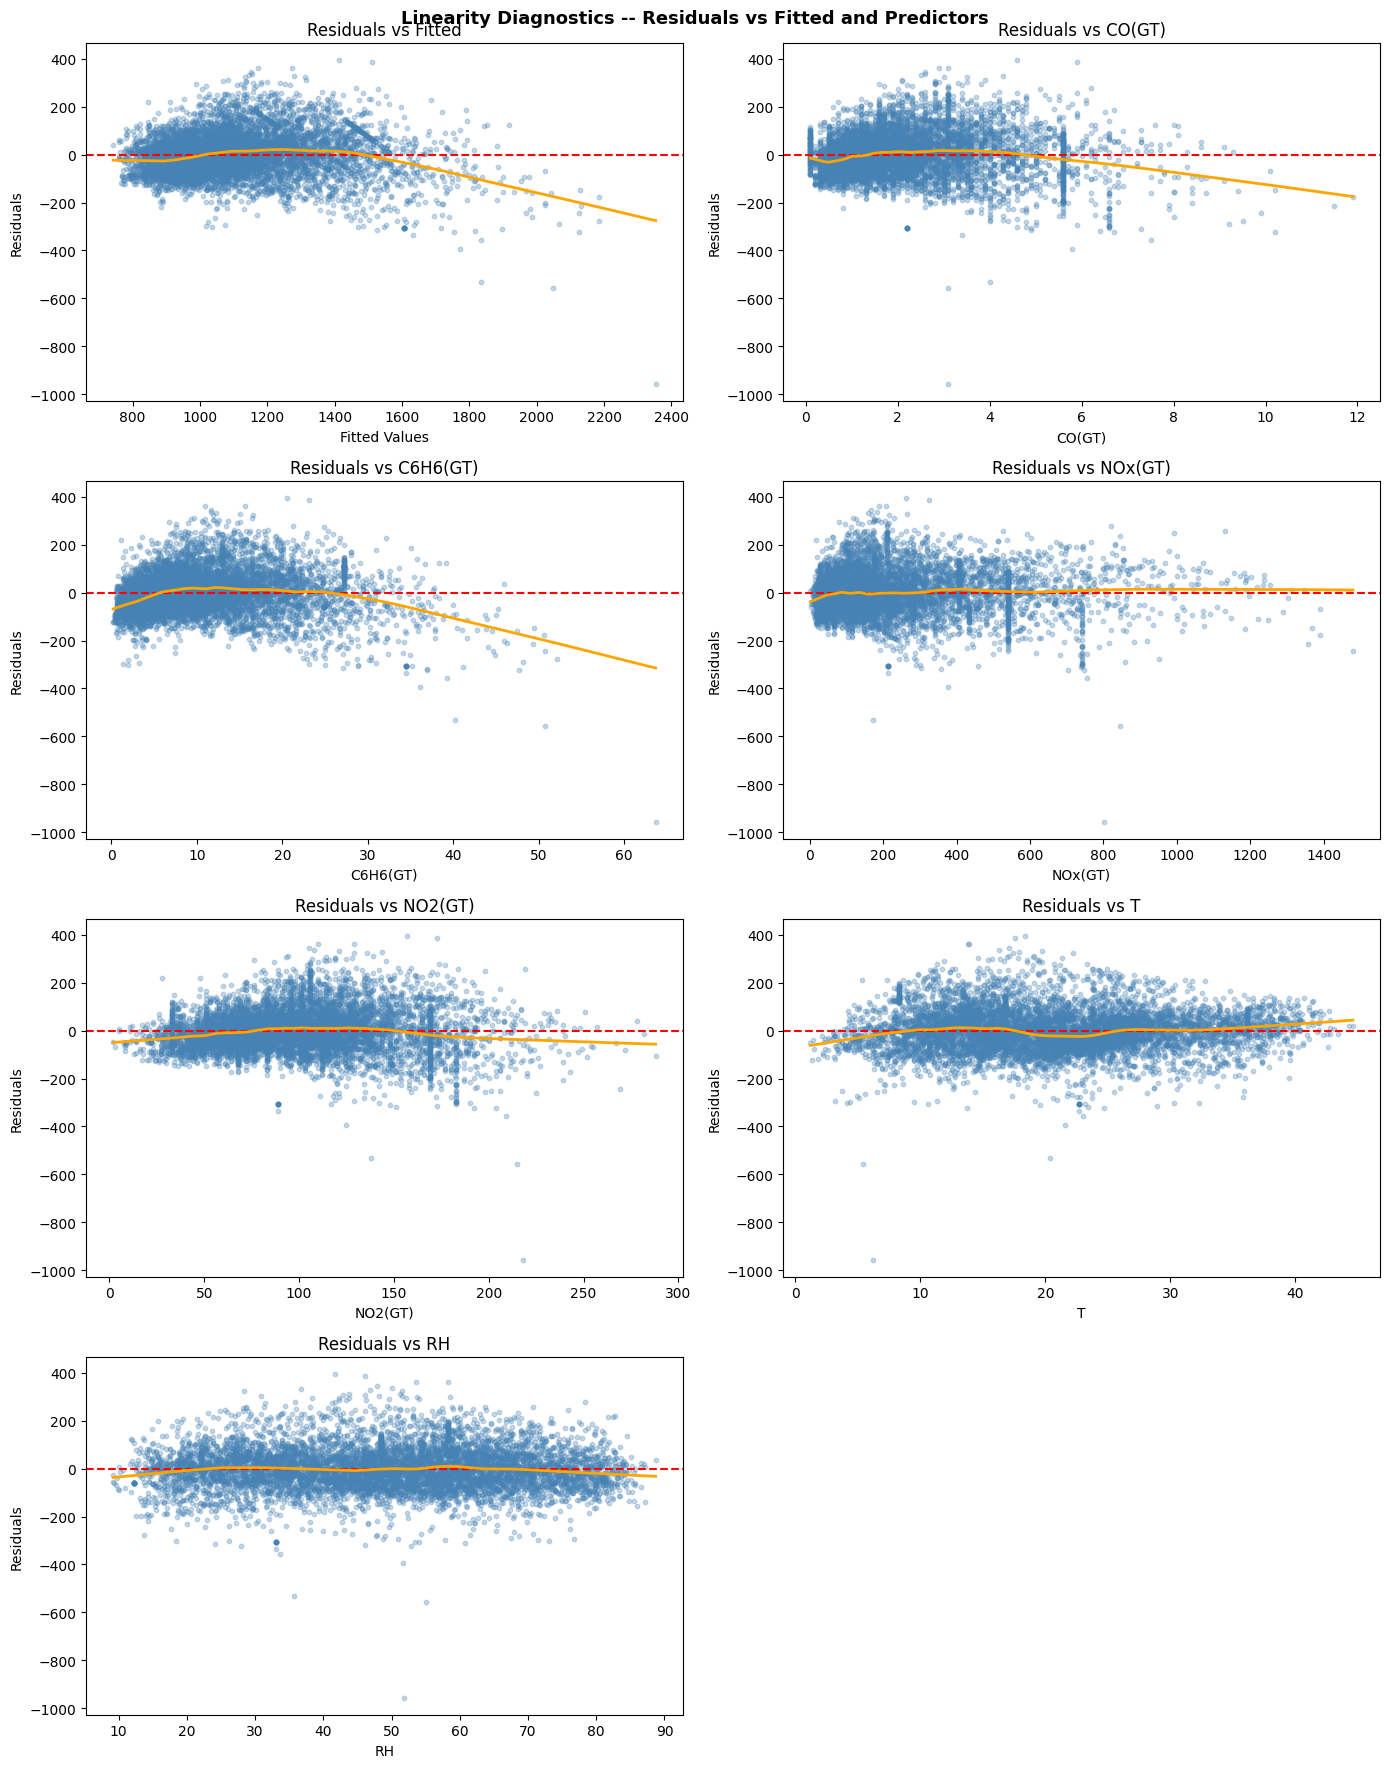

In [147]:
#| echo: false
#| label: fig-air-mlr-linearity
#| fig-cap: "Residuals vs Fitted and Residuals vs each predictor."

residuals = mlr_model.resid
fitted    = mlr_model.fittedvalues

predictor_cols = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
lowess_fit = lowess(residuals, fitted, frac=0.2)
axes[0].plot(lowess_fit[:, 0], lowess_fit[:, 1], color="orange", linewidth=2)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Residuals vs each predictor
for i, col in enumerate(predictor_cols):
    axes[i+1].scatter(train[col], residuals, alpha=0.3, s=10, color="steelblue")
    axes[i+1].axhline(0, color="red", linewidth=1.5, linestyle="--")
    lowess_fit = lowess(residuals, train[col], frac=0.2)
    axes[i+1].plot(lowess_fit[:, 0], lowess_fit[:, 1], color="orange", linewidth=2)
    axes[i+1].set_xlabel(col)
    axes[i+1].set_ylabel("Residuals")
    axes[i+1].set_title(f"Residuals vs {col}")

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Linearity Diagnostics -- Residuals vs Fitted and Predictors",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**(2) Homoscedasticity**

To assess homoscedasticity, we plot the square root of absolute
standardized residuals against fitted values (Scale-Location plot),
with a LOWESS smooth (red line) overlaid. If the constant variance
assumption holds, the LOWESS line should be roughly flat and the
spread of points should be uniform across all fitted values.

From @fig-air-mlr-homoscedasticity, the LOWESS line starts flat
around 0.70 for fitted values between 800 and 1200, then rises
steadily to approximately 1.57 at fitted values above 2000. This
upward trend indicates that residual spread increases with fitted
values -- the constant variance assumption is violated. Additionally,
several extreme points above 2.0 appear at higher fitted values,
further confirming that the model produces larger errors when
predicting high $\text{PT08.S1(CO)}$ sensor responses. This pattern
of heteroscedasticity is consistent with the fanning observed in the
residuals vs fitted plot in (a), and is likely driven by the
right-skewed distributions of $\text{CO(GT)}$ and $\text{C6H6(GT)}$
noted in the EDA.

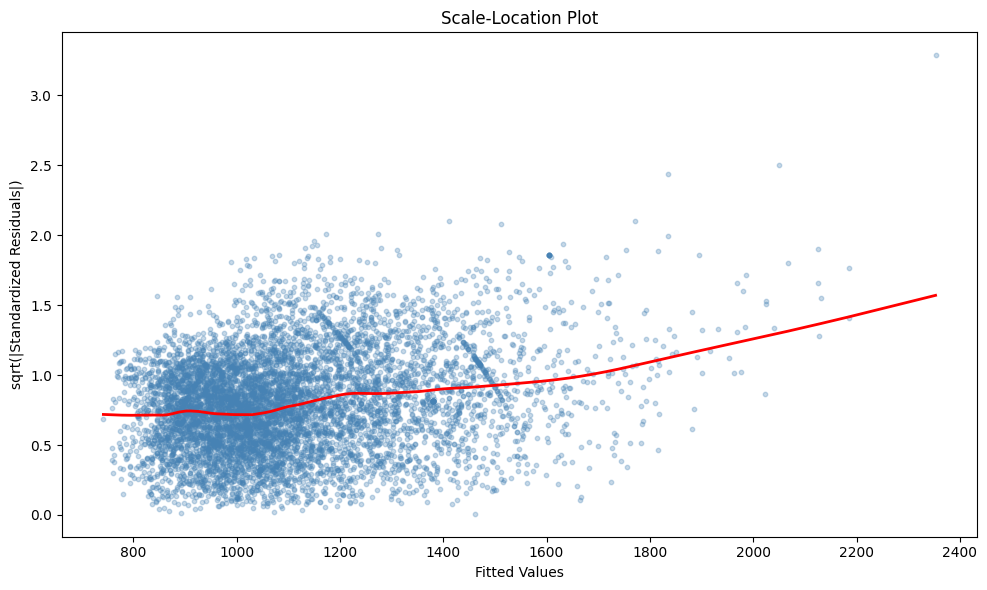

In [148]:
#| echo: false
#| label: fig-air-mlr-homoscedasticity
#| fig-cap: "Scale-Location plot for homoscedasticity assessment."

std_resid  = mlr_model.get_influence().resid_studentized_internal

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(fitted, np.sqrt(np.abs(std_resid)),
           alpha=0.3, s=10, color="steelblue")
lowess_fit = lowess(np.sqrt(np.abs(std_resid)), fitted, frac=0.2)
ax.plot(lowess_fit[:, 0], lowess_fit[:, 1], color="red", linewidth=2)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("sqrt(|Standardized Residuals|)")
ax.set_title("Scale-Location Plot")
plt.tight_layout()
plt.show()

**(3) Normality of Errors**

To assess normality, we plot the sample quantiles of the residuals
against theoretical quantiles from a standard normal distribution
(Q-Q plot), with a reference line (red) representing perfect normality.
If the normality assumption holds, the points should fall closely along
the reference line across the full range.

From @fig-air-mlr-normality, the residuals follow the reference line
closely in the central region (theoretical quantiles between -2 and 2),
suggesting that the bulk of the errors are approximately normally
distributed. However, the plot shows clear departures at both tails.
In the upper tail (theoretical quantiles above 2), points curve slightly
above the reference line, indicating a mild right heavy tail. In the
lower tail, the departures are far more severe -- several points fall
well below the reference line, with residuals reaching as low as -1000,
far beyond what a normal distribution would predict. These extreme
negative residuals correspond to the outliers identified in part (a),
where the model severely under-predicts $\text{PT08.S1(CO)}$ for a
small number of observations. Overall, the normality assumption is
approximately satisfied in the centre but violated in the lower tail,
consistent with the kurtosis of 5.95 reported in the MLR summary.

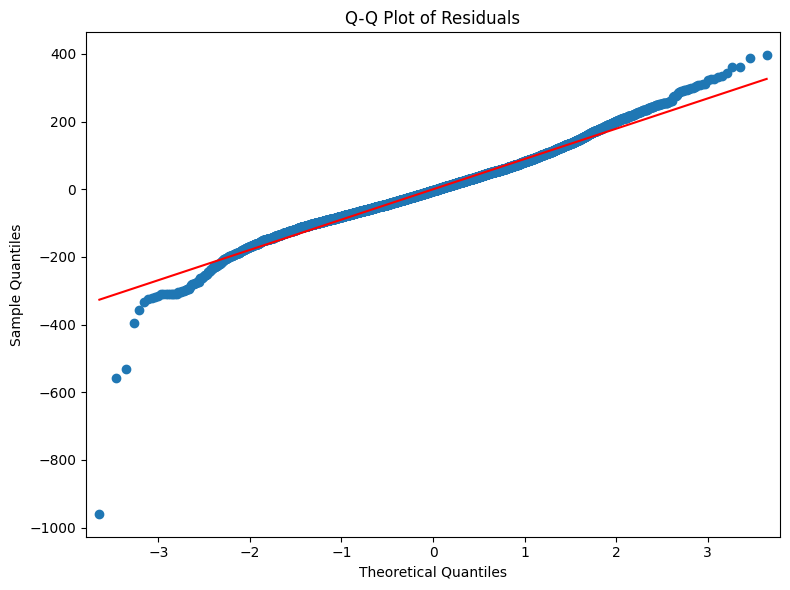

In [149]:
#| echo: false
#| label: fig-air-mlr-normality
#| fig-cap: "Q-Q plot of MLR residuals."

fig, ax = plt.subplots(figsize=(8, 6))
qqplot(residuals, line="s", ax=ax)
ax.set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

**(d) Outliers and Influence**

To identify influential observations, we compute leverage and Cook's
distance for each training observation. Leverage measures how far an
observation's predictor values are from the mean of all predictors --
high leverage points have unusual $X$ values. Cook's distance combines
leverage and residual size to measure the overall influence of each
observation on the fitted model. The thresholds used are $2p/n$ for
leverage and $4/n$ for Cook's distance, where $p$ is the number of
predictors and $n$ is the training sample size.

From @fig-air-mlr-influence, the leverage plot shows that most
observations fall below the threshold of $2p/n = 0.00187$, but a
cluster of points around index 6000-6200 exceeds the threshold,
with one observation reaching a leverage of 0.0170. The Cook's
distance plot reveals one dominant influential point near index
6100 with Cook's distance of 0.253, far exceeding the threshold
of $4/n = 0.00053$, and a few smaller spikes around index 1800
and 4500.

From @tbl-air-mlr-influential, the top 3 most influential
observations share a common pattern -- all three have large
negative residuals (−959, −557, and −532), meaning the model
substantially over-predicts $\text{PT08.S1(CO)}$ for these
hours. The most influential observation (Cook's $D$ = 0.253)
has an unusually high $\text{C6H6(GT)}$ of 63.7 microg/m3
and $\text{NOx(GT)}$ of 801 ppb alongside a very low
$\text{PT08.S1(CO)}$ of 1394, which is inconsistent with
what the model expects given those pollutant levels. These
observations are physically plausible -- they likely correspond
to specific pollution events where sensor response did not scale
proportionally with ground truth concentrations, possibly due
to sensor drift or cross-sensitivity effects documented in the
original dataset. While influential, removing them is not
recommended without further investigation as they may represent
real extreme pollution events.

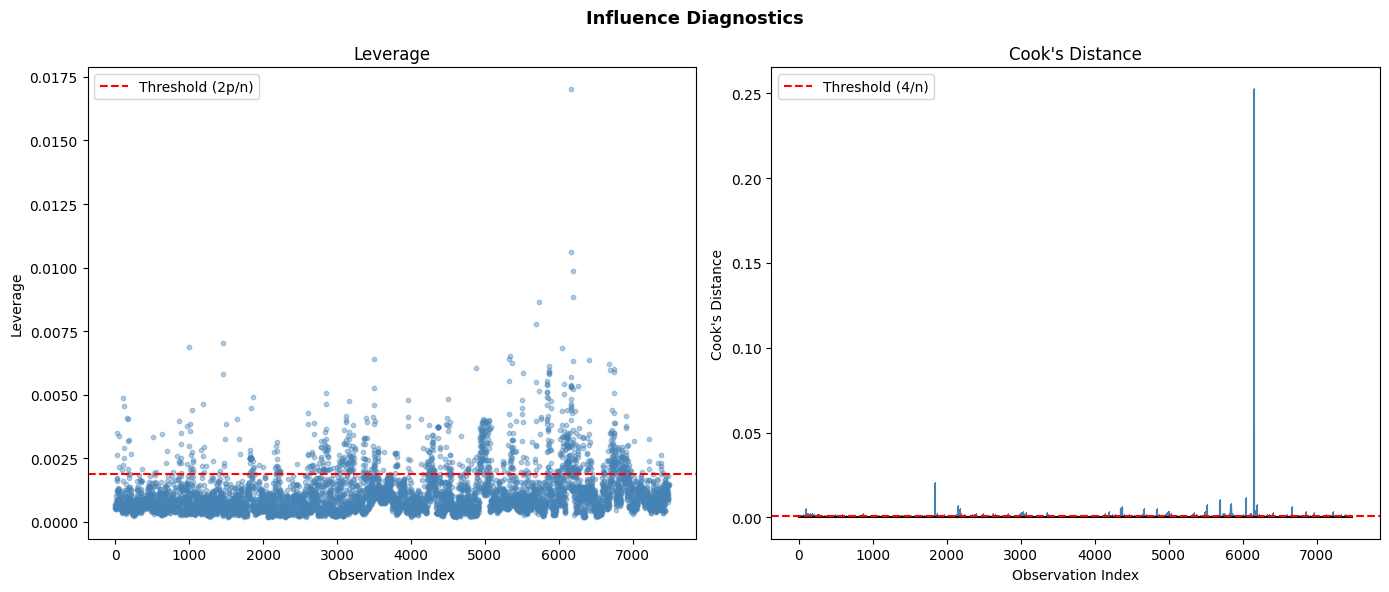

In [150]:
#| echo: false
#| label: fig-air-mlr-influence
#| fig-cap: "Leverage and Cook's Distance for influential point detection."

influence = mlr_model.get_influence()
leverage  = influence.hat_matrix_diag
cooks_d   = influence.cooks_distance[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Leverage plot
axes[0].scatter(range(len(leverage)), leverage,
                alpha=0.4, s=10, color="steelblue")
axes[0].axhline(2 * mlr_model.df_model / mlr_model.nobs,
                color="red", linestyle="--", linewidth=1.5,
                label="Threshold (2p/n)")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Leverage")
axes[0].set_title("Leverage")
axes[0].legend()

# Cook's Distance plot
axes[1].stem(range(len(cooks_d)), cooks_d,
             markerfmt=",", linefmt="steelblue", basefmt="black")
axes[1].axhline(4 / mlr_model.nobs, color="red", linestyle="--",
                linewidth=1.5, label="Threshold (4/n)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Cook's Distance")
axes[1].set_title("Cook's Distance")
axes[1].legend()

plt.suptitle("Influence Diagnostics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [151]:
#| echo: false
#| label: tbl-air-mlr-influential
#| tbl-cap: "Top 3 most influential observations by Cook's distance."

top3_idx = np.argsort(cooks_d)[::-1][:3]

top3_df = train.iloc[top3_idx].copy()
top3_df["Cook's D"] = cooks_d[top3_idx].round(6)
top3_df["Leverage"] = leverage[top3_idx].round(6)
top3_df["Residual"] = residuals.iloc[top3_idx].round(4)

display(top3_df[["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)",
                 "T", "RH", "AH", "PT08.S1(CO)",
                 "Cook's D", "Leverage", "Residual"]])

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH,PT08.S1(CO),Cook's D,Leverage,Residual
6160,3.1,63.7,801.0,218.0,6.2,51.8,0.4952,1394.0,0.252747,0.017035,-959.0123
6159,3.1,50.7,846.0,215.0,5.4,55.1,0.4970,1493.0,0.052464,0.010630,-556.7119
1839,4.0,40.2,173.0,138.0,20.4,35.7,0.8440,1303.0,0.019984,0.004481,-532.4732


### 3. Ridge and Lasso Regression

**Ridge Regression** minimizes the penalized residual sum of squares:

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}\beta_j^2$$

**Lasso Regression** minimizes:

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}|\beta_j|$$

where $\lambda \geq 0$ is the tuning parameter controlling the strength
of regularization. A larger $\lambda$ shrinks coefficients more
aggressively. Ridge shrinks all coefficients toward zero but retains
all predictors, while Lasso can shrink some coefficients to exactly
zero, performing automatic variable selection.

**(a)** To fit Ridge and Lasso regression, predictors are first
standardized by subtracting the mean and dividing by the standard
deviation, which is required for regularization to treat all
predictors equally regardless of their scale. A grid of 200 $\lambda$
values is searched over the range $[10^{-3}, 10^{6}]$ using 5-fold
cross-validation on the training set to select the optimal tuning
parameter.

Ridge regression selected $\lambda = 7488.10$, indicating that a
strong L2 penalty is needed to shrink the coefficients given the
high multicollinearity observed among predictors. Lasso regression
selected a much smaller $\lambda = 69.06$, reflecting that the L1
penalty requires less shrinkage to achieve stable estimates while
also performing variable selection.

In [152]:
#| echo: false
#| label: tbl-air-ridge-lasso-fit
#| tbl-cap: "Ridge and Lasso regression with 5-fold cross-validation."

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import Pipeline

# Define predictors and response
X_train = train[["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"]]
X_test  = test[["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"]]
y_train = train["PT08.S1(CO)"]
y_test  = test["PT08.S1(CO)"]

# Lambda search range
alphas = np.logspace(-3, 6, 200)

# Ridge with 5-fold CV
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)

# Lasso with 5-fold CV
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)

print(f"Ridge selected λ : {ridge_cv.alpha_:.4f}")
print(f"Lasso selected λ : {lasso_cv.alpha_:.4f}")

Ridge selected λ : 7488.1039
Lasso selected λ : 69.0551


**(b)** After fitting Ridge and Lasso with the selected $\lambda$ values,
we evaluate cross-validated predictive performance on both training and
test sets using RMSE and $R^2$.

From @tbl-air-ridge-lasso-perf, both Ridge and Lasso achieve strong
predictive performance. Ridge obtains a test RMSE of 81.29 and test
$R^2$ of 0.8420, while Lasso achieves a test RMSE of 80.19 and test
$R^2$ of 0.8462, making Lasso slightly better on the test set. Both
models show a small gap between train and test $R^2$, indicating good
generalization with no overfitting. From @tbl-air-ridge-lasso-coef,
Lasso shrinks the coefficients of $\text{CO(GT)}$, $T$, and $\text{AH}$
exactly to zero, retaining only $\text{C6H6(GT)}$, $\text{NOx(GT)}$,
$\text{NO2(GT)}$, and $\text{RH}$ as active predictors.

In [167]:
#| echo: false
#| label: tbl-air-ridge-lasso-perf
#| tbl-cap: "Ridge and Lasso cross-validated performance."

# Predictions
ridge_train_pred = ridge_cv.predict(X_train)
ridge_test_pred  = ridge_cv.predict(X_test)
lasso_train_pred = lasso_cv.predict(X_train)
lasso_test_pred  = lasso_cv.predict(X_test)

# Performance table
perf_df = pd.DataFrame({
    "Model":      ["Ridge", "Lasso"],
    "Selected λ": [round(ridge_cv.alpha_, 4), round(lasso_cv.alpha_, 4)],
    "Train RMSE": [
        round(np.sqrt(mean_squared_error(y_train, ridge_train_pred)), 4),
        round(np.sqrt(mean_squared_error(y_train, lasso_train_pred)), 4)
    ],
    "Test RMSE": [
        round(np.sqrt(mean_squared_error(y_test, ridge_test_pred)), 4),
        round(np.sqrt(mean_squared_error(y_test, lasso_test_pred)), 4)
    ],
    "Train R2": [
        round(r2_score(y_train, ridge_train_pred), 4),
        round(r2_score(y_train, lasso_train_pred), 4)
    ],
    "Test R2": [
        round(r2_score(y_test, ridge_test_pred), 4),
        round(r2_score(y_test, lasso_test_pred), 4)
    ]
})
display(perf_df)

,Model,Selected λ,Train RMSE,Test RMSE,Train R2,Test R2
0,Ridge,7488.1039,90.1285,81.2914,0.8367,0.8420
1,Lasso,69.0551,91.9920,80.1923,0.8299,0.8462


In [168]:
#| echo: false
#| label: tbl-air-ridge-lasso-coef
#| tbl-cap: "Ridge and Lasso estimated coefficients."

coef_df = pd.DataFrame({
    "Predictor":  ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"],
    "Ridge Coef": ridge_cv.coef_.round(4),
    "Lasso Coef": lasso_cv.coef_.round(4)
})
display(coef_df)

,Predictor,Ridge Coef,Lasso Coef
0,CO(GT),8.3361,0.0000
1,C6H6(GT),23.2194,22.3539
2,NOx(GT),-0.1489,-0.0627
3,NO2(GT),1.0963,1.0481
4,T,0.2642,0.0000
5,RH,2.7159,2.1867
6,AH,0.4325,0.0000


**(c)** From @tbl-air-model-comparison and @fig-air-mlr-coef-comparison,
we compare MLR, Ridge, and Lasso across predictive accuracy,
interpretability, and the effect of regularization on collinearity.

**Predictive Accuracy:** MLR achieves the highest train $R^2$ (0.8389)
but the worst test $R^2$ (0.8229) and test RMSE (86.06), suggesting
mild overfitting due to multicollinearity. Ridge improves test
performance with test $R^2$ of 0.8420 and test RMSE of 81.29, while
Lasso achieves the best test $R^2$ (0.8462) and lowest test RMSE
(80.19), indicating that regularization improves generalization beyond
what OLS alone can achieve.

**Interpretability:** MLR retains all 7 predictors with unpenalized
coefficients, making it straightforward to interpret. Ridge also
retains all 7 predictors but shrinks coefficients toward zero --
notably $\text{CO(GT)}$ drops from 21.70 (MLR) to 8.34 (Ridge) and
$\text{AH}$ drops dramatically from 13.55 to 0.43, reflecting their
instability under multicollinearity. Lasso is the most interpretable
-- it shrinks $\text{CO(GT)}$, $T$, and $\text{AH}$ exactly to zero,
retaining only 4 active predictors: $\text{C6H6(GT)}$,
$\text{NOx(GT)}$, $\text{NO2(GT)}$, and $\text{RH}$, identifying
these as the most influential predictors of $\text{PT08.S1(CO)}$.

**Effect of Regularization on Collinearity:** The MLR diagnostics
flagged a condition number of 4,120 and a large unstable coefficient
for $\text{AH}$ (13.55, p = 0.082), both indicating multicollinearity.
Ridge addresses this by distributing the penalty across all correlated
predictors, stabilizing the coefficients without eliminating any.
Lasso goes further by zeroing out the most collinear and weakly
contributing predictors ($\text{CO(GT)}$, $T$, $\text{AH}$),
producing a sparser and more stable model. The improvement in test
performance from MLR to Lasso confirms that multicollinearity was
inflating variance in the OLS estimates.

In [154]:
#| echo: false
#| label: tbl-air-model-comparison
#| tbl-cap: "Comparison of MLR, Ridge, and Lasso regression performance."
comparison_df = pd.DataFrame({
    "Model":      ["MLR", "Ridge", "Lasso"],
    "Train RMSE": [89.5017, 90.1285, 91.9920],
    "Test RMSE":  [86.0606, 81.2914, 80.1923],
    "Train R2":   [0.8389, 0.8367, 0.8299],
    "Test R2":    [0.8229, 0.8420, 0.8462]
})
display(comparison_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,MLR,89.5017,86.0606,0.8389,0.8229
1,Ridge,90.1285,81.2914,0.8367,0.8420
2,Lasso,91.9920,80.1923,0.8299,0.8462


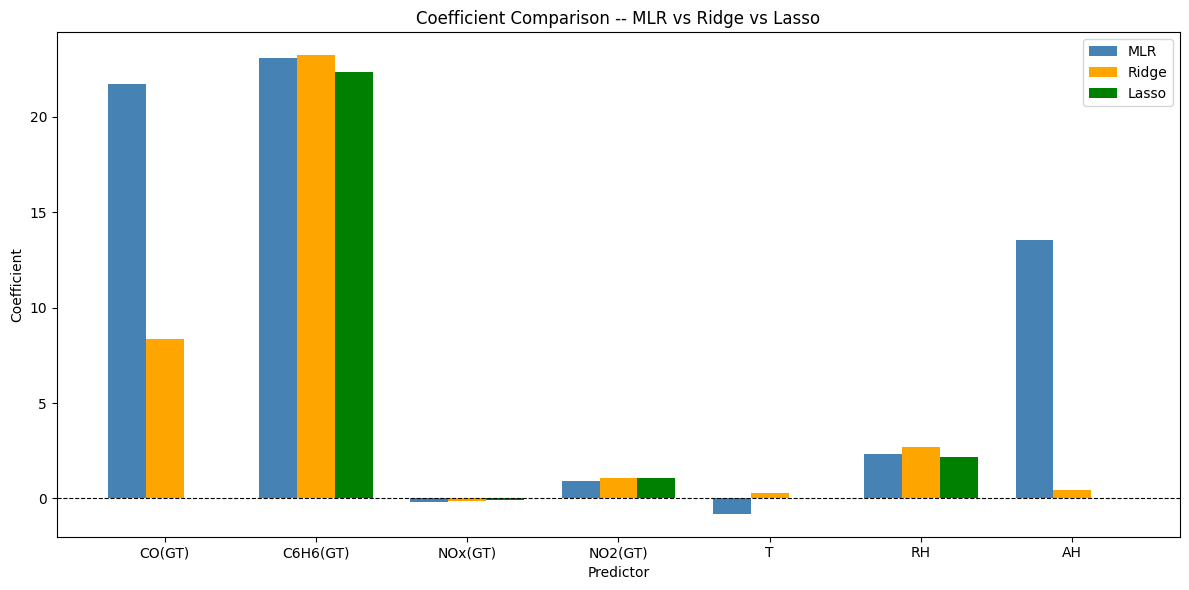

In [155]:
#| echo: false
#| label: fig-air-mlr-coef-comparison
#| fig-cap: "Coefficient Comparison -- MLR vs Ridge vs Lasso"
coef_compare = pd.DataFrame({
    "Predictor":  ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"],
    "MLR":        [21.6969, 23.0923, -0.1939, 0.9012, -0.8041, 2.3214, 13.5528],
    "Ridge":      [8.3361,  23.2194, -0.1489,  1.0963,  0.2642,  2.7159,  0.4325],
    "Lasso":      [0.0000,  22.3539, -0.0627,  1.0481,  0.0000,  2.1867,  0.0000]
})
x = np.arange(len(coef_compare["Predictor"]))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, coef_compare["MLR"],   width, label="MLR",   color="steelblue")
ax.bar(x,         coef_compare["Ridge"], width, label="Ridge", color="orange")
ax.bar(x + width, coef_compare["Lasso"], width, label="Lasso", color="green")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(coef_compare["Predictor"])
ax.set_xlabel("Predictor")
ax.set_ylabel("Coefficient")
ax.set_title("Coefficient Comparison -- MLR vs Ridge vs Lasso")
ax.legend()
plt.tight_layout()
plt.show()

## Result & Model Selecting

**Data Summary**

After removing $\text{NMHC(GT)}$ due to 90.23% missingness and applying
forward fill to the remaining missing values, the final dataset retains
all 9,357 rows across 7 predictors -- $\text{CO(GT)}$, $\text{C6H6(GT)}$,
$\text{NOx(GT)}$, $\text{NO2(GT)}$, $T$, $\text{RH}$, and $\text{AH}$ --
and $\text{PT08.S1(CO)}$ as the response variable. The dataset was split
80/20 by time order into a training set (7,485 observations) and a test
set (1,872 observations).

**Model Performance Summary**

From @tbl-air-final-comparison, all four models show consistent improvement
as complexity increases. SLR, using only $\text{CO(GT)}$ as a predictor,
achieves a test $R^2$ of 0.5835 and test RMSE of 131.97, explaining only
58% of the variation in $\text{PT08.S1(CO)}$. Adding all 7 predictors in
MLR substantially improves performance, with test $R^2$ rising to 0.8229
and test RMSE dropping to 86.06. Ridge and Lasso further improve
generalization through regularization -- Ridge achieves test $R^2$ of
0.8420 and test RMSE of 81.29, while Lasso achieves the best test $R^2$
of 0.8462 and lowest test RMSE of 80.19 using only 4 predictors.

**Assumption Diagnostics Summary**

The MLR diagnostics revealed three key violations. First, the residuals
vs fitted plot in @fig-air-mlr-linearity showed a downward-curving LOWESS
trend at high fitted values, indicating mild non-linearity, particularly
for $\text{CO(GT)}$ and $\text{C6H6(GT)}$ at extreme concentrations.
Second, the Scale-Location plot in @fig-air-mlr-homoscedasticity showed
an upward-sloping LOWESS trend from 0.70 to 1.57, confirming
heteroscedasticity -- residual spread increases with fitted values.
Third, the Q-Q plot in @fig-air-mlr-normality showed heavy lower-tail
departures with residuals reaching as low as -1000, driven by the three
influential observations identified in @tbl-air-mlr-influential, which
had Cook's distances of 0.2527, 0.0525, and 0.0200 respectively.
The MLR summary also flagged a condition number of 4,120, confirming
strong multicollinearity among predictors.

**Model Selection**

Based on @tbl-air-final-comparison, **Lasso** is selected as the best
model. It achieves the highest test $R^2$ (0.8462) and lowest test RMSE
(80.19) among all four models, outperforming MLR by 5.87 RMSE units on
the test set. Beyond predictive accuracy, Lasso addresses the
multicollinearity flagged in diagnostics by shrinking $\text{CO(GT)}$,
$T$, and $\text{AH}$ exactly to zero, retaining only 4 active predictors:
$\text{C6H6(GT)}$, $\text{NOx(GT)}$, $\text{NO2(GT)}$, and $\text{RH}$,
as shown in @fig-air-mlr-coef-comparison. This produces a sparser and
more interpretable model while improving generalization. The small gap
between Lasso's train $R^2$ (0.8299) and test $R^2$ (0.8462) further
confirms stable generalization with no overfitting.

**Limitations**

Despite strong performance, the selected Lasso model has several
limitations. The heteroscedasticity identified in @fig-air-mlr-homoscedasticity
suggests that prediction errors are larger at high sensor responses,
meaning the model is less reliable for extreme pollution events. The
three influential observations in @tbl-air-mlr-influential, with
residuals of -959, -557, and -532, indicate the model struggles with
sudden pollution spikes. Additionally, the forward fill applied during
data cleaning introduced artificial vertical bands visible in
@fig-air-slr-fit and @fig-air-mlr-linearity, which may have slightly
inflated model performance by reducing true variability in the data.

In [156]:
#| echo: false
#| label: tbl-air-final-comparison
#| tbl-cap: "Summary of all model performance metrics."

final_comparison = pd.DataFrame({
    "Model":      ["SLR", "MLR", "Ridge", "Lasso"],
    "Predictors": [1, 7, 7, 4],
    "Train RMSE": [144.2474, 89.5017, 90.1285, 91.9920],
    "Test RMSE":  [131.9696, 86.0606, 81.2914, 80.1923],
    "Train R2":   [0.5817, 0.8389, 0.8367, 0.8299],
    "Test R2":    [0.5835, 0.8229, 0.8420, 0.8462]
})
display(final_comparison)

,Model,Predictors,Train RMSE,Test RMSE,Train R2,Test R2
0,SLR,1,144.2474,131.9696,0.5817,0.5835
1,MLR,7,89.5017,86.0606,0.8389,0.8229
2,Ridge,7,90.1285,81.2914,0.8367,0.8420
3,Lasso,4,91.9920,80.1923,0.8299,0.8462


## Discussion, Conclusion & Future Work

**Discussion**

This report set out to investigate whether ground truth pollutant
concentrations and environmental variables could reliably predict the
$\text{PT08.S1(CO)}$ tin oxide sensor response, as a proxy for
low-cost sensor calibration in urban air quality monitoring. The
results confirm that this is achievable to a high degree -- the best
model, Lasso, explains 84.62% of the variation in $\text{PT08.S1(CO)}$
on unseen test data with a test RMSE of 80.19, using only 4 predictors:
$\text{C6H6(GT)}$, $\text{NOx(GT)}$, $\text{NO2(GT)}$, and $\text{RH}$.
This is consistent with the physical understanding of the sensor --
Benzene ($\text{C6H6}$) is the strongest individual predictor
(r = 0.886), reflecting the known cross-sensitivity of tin oxide
sensors to aromatic hydrocarbons documented in De Vito et al. (2008).
The fact that $\text{CO(GT)}$ -- the pollutant the sensor nominally
targets -- was zeroed out by Lasso is a notable finding, suggesting
that in the presence of correlated pollutants, Benzene concentration
is a more stable and informative predictor of this sensor's response
than CO itself. This highlights the cross-sensitivity problem at the
core of metal oxide sensor calibration and demonstrates the value of
regularization methods in identifying the true drivers of sensor
behavior.

However, several important limitations were uncovered. The assumption
diagnostics revealed clear heteroscedasticity -- residual spread
increases with fitted values -- meaning the model is less reliable
at predicting high sensor responses corresponding to extreme pollution
events. The Q-Q plot showed heavy lower-tail departures with residuals
reaching as low as -1000, driven by a small number of highly
influential observations identified through Cook's distance analysis.
These observations likely correspond to sudden pollution spikes or
sensor anomalies that the linear model cannot capture. Furthermore,
the forward fill applied during data cleaning, while appropriate for
a time-series dataset, introduced artificial continuity around missing
value blocks, which may have slightly inflated model performance by
reducing true variability. What this analysis did not explore includes
temporal patterns -- hour of day and seasonal effects -- which the
EDA suggested are present in the data through the bimodal distribution
of temperature and the time-series structure of pollutant
concentrations.

**Conclusion**

This report demonstrated that linear regression methods, particularly
Lasso regression, can effectively calibrate metal oxide sensor
responses using ground truth pollutant concentrations and environmental
variables. Starting from a baseline SLR model with test $R^2$ of
0.5835, performance improved substantially through MLR (0.8229),
Ridge (0.8420), and finally Lasso (0.8462), with each step motivated
by the multicollinearity and assumption violations identified in
diagnostics. Lasso is selected as the final model for its superior
predictive accuracy, interpretability, and automatic variable
selection, reducing the predictor set from 7 to 4 while improving
generalization. The analysis confirms that cheap sensor responses can
be reliably estimated from reference measurements, supporting the
broader goal of scalable low-cost air quality monitoring in urban
environments.

**Future Work**

Several directions could extend this analysis. First, non-linear
models such as Random Forest or Gradient Boosting could address the
heteroscedasticity and non-linearity observed in diagnostics, likely
improving performance at extreme pollution levels. Second, temporal
features such as hour of day, day of week, and month could be
engineered from the datetime index to capture diurnal and seasonal
patterns not exploited in the current models. Third, the three
remaining sensor responses -- $\text{PT08.S2(NMHC)}$,
$\text{PT08.S3(NOx)}$, $\text{PT08.S4(NO2)}$, and
$\text{PT08.S5(O3)}$ -- could be modeled using the same pipeline to
provide a complete multi-output sensor calibration framework. Finally,
robust regression methods or log transformations of skewed predictors
could be explored to address the heavy-tailed residuals and
influential observations identified in the Cook's distance analysis.

## References

De Vito, S., Massera, E., Piga, M., Martinotto, L., & Di Francia, G.
(2008). On field calibration of an electronic nose for benzene
estimation in an urban pollution monitoring scenario.
*Sensors and Actuators B: Chemical*, 129(2), 750--757.
https://doi.org/10.1016/j.snb.2007.09.060

Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased
estimation for nonorthogonal problems. *Technometrics*, 12(1), 55--67.
https://doi.org/10.1080/00401706.1970.10488634

Tibshirani, R. (1996). Regression shrinkage and selection via the
lasso. *Journal of the Royal Statistical Society: Series B
(Methodological)*, 58(1), 267--288.
https://doi.org/10.1111/j.2517-6161.1996.tb02080.x

Dua, D., & Graff, C. (2019). UCI Machine Learning Repository.
University of California, Irvine, School of Information and Computer
Sciences. https://archive.ics.uci.edu/dataset/360/air+quality

## Appendix

All code, data, and outputs for this project are available at:

[https://github.com/3313556500/210P-Final-Project---Tao-Chen.git](https://github.com/3313556500/210P-Final-Project---Tao-Chen.git)